# OSM Buildings + Census Join

This notebook:

1. Loads a **boundary** GeoJSON (the area of interest).
2. Fetches **building footprints** from OpenStreetMap within that boundary using `osmnx`.
3. Loads a **census** GeoJSON (e.g. tracts/block groups with demographic attributes).
4. Spatially joins the census attributes onto each building polygon.
5. Exports the result to a new GeoJSON.

**Before running:** update the file paths in the "Configuration" cell below to point to your own boundary and census files.


In [45]:
import geopandas as gpd
import osmnx as ox
from shapely.geometry import shape
import matplotlib.pyplot as plt
import subprocess
from pathlib import Path


# osmnx settings: keep the full tag set that comes back from Overpass
ox.settings.log_console = False
ox.settings.use_cache = True


## 1. Configuration

Set the paths to your input files and the tags you want to pull from OSM.


In [46]:
BOUNDARY_PATH = "../../data/geo/regions/toronto-boundary.geojson"     # polygon defining your area of interest
CENSUS_PATH = "../../data/census/ada-wide/ada-wide-tts.geojson"         # census polygons (tracts, block groups, etc.) with attribute columns
OUTPUT_PATH = "../../data/census/ada-wide/buildings_with_census.geojson"

# OSM tags to fetch - `True` means "any value for this key"
OSM_TAGS = {"building": True}

## 2. Load the boundary

The boundary file defines the area we'll query OSM for. If it has multiple
features, they are dissolved into a single polygon (OSM queries need one
geometry to clip against).


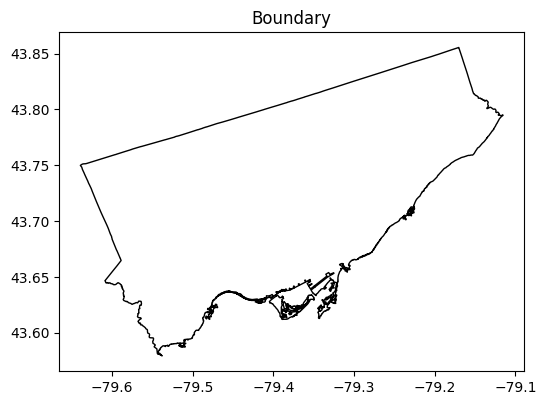

In [47]:
boundary_gdf = gpd.read_file(BOUNDARY_PATH)
boundary_gdf["geometry"] = boundary_gdf.geometry.make_valid().iloc[[0]]  # Fix any invalid geometries

# Make sure we're in WGS84 (EPSG:4326), which is what OSM/osmnx expects
if boundary_gdf.crs is None:
    boundary_gdf = boundary_gdf.set_crs(4326)
else:
    boundary_gdf = boundary_gdf.to_crs(4326)

# Dissolve to a single (multi)polygon in case there are several features
boundary_polygon = boundary_gdf.union_all() if hasattr(boundary_gdf, "union_all") else boundary_gdf.unary_union

boundary_gdf.plot(edgecolor="black", facecolor="none", figsize=(6, 6))
plt.title("Boundary")
plt.show()


## 3. Fetch building footprints from OSM

Uses `osmnx.features_from_polygon`, which queries the Overpass API for all
elements matching `OSM_TAGS` within the given polygon and returns them as a
GeoDataFrame (points, lines, and polygons can all come back - we filter down
to polygons since we want building footprints).


In [48]:
raw_buildings = ox.features_from_polygon(boundary_polygon, tags=OSM_TAGS)

# Keep only polygon/multipolygon geometries (drop stray points/lines OSM sometimes returns)
buildings = raw_buildings[raw_buildings.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()

# osmnx returns the OSM id as part of a MultiIndex (element_type, osmid) - flatten it into a column
buildings = buildings.reset_index()

print(f"Fetched {len(buildings)} building polygons")
buildings.head()


Fetched 424113 building polygons


,element,id,geometry,building,name,opening_hours,wikidata,note,addr:city,addr:housenumber,...,hot_water,supervised,crop,source:geometry:date,sells,addr:full,note_2,network:wikidata,addr:housenumber2,stairwell
0,relation,1989,"POLYGON ((-79.3952 43.6641, -79.39512 43.66412...",university,Hart House,Mo-Su 07:00-24:00,Q5674187,open 365 days a year,Toronto,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,relation,2032,"POLYGON ((-79.39637 43.6616, -79.39639 43.6615...",university,Knox College,NaN,Q593199,NaN,Toronto,59,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,relation,2152,"POLYGON ((-79.39981 43.66042, -79.39985 43.660...",university,Earth Sciences Centre,NaN,NaN,NaN,Toronto,NaN,...,NaN,NaN,NaN,NaN,NaN,"33 Willcocks Street, 25 Willcocks Street, 22 R...",NaN,NaN,NaN,NaN
3,relation,2687,"POLYGON ((-79.39546 43.66589, -79.39542 43.665...",university,Trinity College,NaN,NaN,NaN,Toronto,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,relation,3113,"POLYGON ((-79.39937 43.65972, -79.39901 43.659...",hospital,NaN,NaN,NaN,NaN,NaN,33,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Trim down columns (optional but recommended)

OSM features can come back with dozens of sparse tag columns. Keep the ones
you care about plus geometry so the export stays manageable.


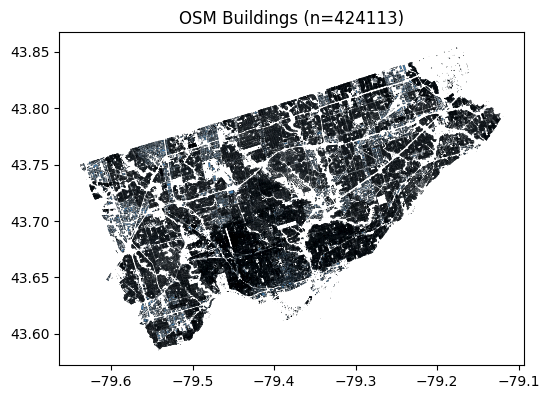

In [49]:
keep_cols = [c for c in ["osmid", "element_type", "building", "name", "addr:housenumber",
                          "addr:street", "building:levels", "geometry"] if c in buildings.columns]
buildings = buildings[keep_cols]

buildings = buildings.set_geometry("geometry")
buildings = buildings.set_crs(4326, allow_override=True)

buildings.plot(figsize=(6, 6), color="steelblue", edgecolor="black", linewidth=0.2)
plt.title(f"OSM Buildings (n={len(buildings)})")
plt.show()


/var/folders/69/g590bg750s935v88zgfrdm9w0000gn/T/ipykernel_47684/2092717894.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  areas = buildings.geometry.area.values


Dissolved 424113 raw footprints into 423961 buildings (merged 152 footprints with >= 50% overlap)


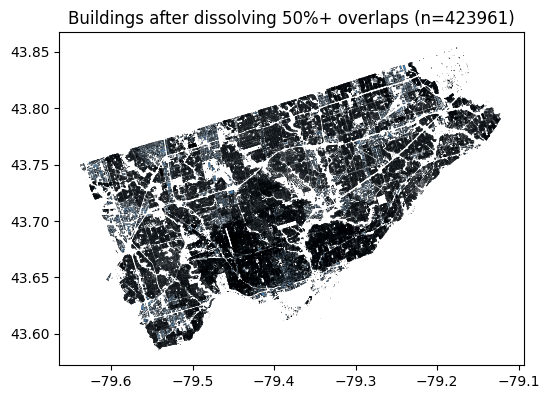

In [50]:
from shapely.ops import unary_union

OVERLAP_THRESHOLD = 0.5  # fraction of the smaller polygon's area that must be covered

buildings = buildings.reset_index(drop=True)
n = len(buildings)
geoms = buildings.geometry.values
areas = buildings.geometry.area.values
sindex = buildings.sindex

# --- Union-find over buildings whose overlap ratio clears the threshold ---
parent = list(range(n))

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[rb] = ra

for i, geom in enumerate(geoms):
    for j in sindex.query(geom, predicate="intersects"):
        if j <= i or find(i) == find(j):
            continue
        inter_area = geom.intersection(geoms[j]).area
        overlap_ratio = inter_area / min(areas[i], areas[j])
        if overlap_ratio >= OVERLAP_THRESHOLD:
            union(i, j)

buildings["_cluster"] = [find(i) for i in range(n)]
buildings["_area"] = areas
n_before = n
n_clusters = buildings["_cluster"].nunique()

# Merge geometries within each cluster, keep the attributes of the largest member
merged_geom = buildings.groupby("_cluster")["geometry"].agg(lambda gs: unary_union(list(gs)))
attrs = (
    buildings.drop(columns="geometry")
    .sort_values("_area", ascending=False)
    .drop_duplicates(subset="_cluster", keep="first")
    .set_index("_cluster")
)

buildings = attrs.join(merged_geom).drop(columns="_area").reset_index(drop=True)
buildings = gpd.GeoDataFrame(buildings, geometry="geometry", crs="EPSG:4326")

print(f"Dissolved {n_before} raw footprints into {n_clusters} buildings "
      f"(merged {n_before - n_clusters} footprints with >= {OVERLAP_THRESHOLD:.0%} overlap)")

buildings.plot(figsize=(6, 6), color="steelblue", edgecolor="black", linewidth=0.2)
plt.title(f"Buildings after dissolving {OVERLAP_THRESHOLD:.0%}+ overlaps (n={len(buildings)})")
plt.show()

## 5. Load the census GeoJSON

This should be polygons (e.g. tracts, block groups, ZCTAs) with the
demographic/economic attribute columns you want attached to each building.


In [51]:
census_gdf = gpd.read_file(CENSUS_PATH)

if census_gdf.crs is None:
    census_gdf = census_gdf.set_crs(4326)
else:
    census_gdf = census_gdf.to_crs(4326)

print(f"Loaded {len(census_gdf)} census polygons")
census_gdf.head()


Loaded 279 census polygons


,ADAUID,age_median_count,citizen_canadian_pct,education_bachelor_higher_pct,education_none_pct,education_secondary_pct,gini_total_income_count,housing_core_need_yes_pct,housing_shelter_30plus_pct,housing_tenure_renter_pct,income_aftertax_median_count,labour_industry_71_arts_pct,labour_occupation_5_arts_culture_pct,lim_at_prev_pct,pop_2021_count,pop_density_pct,pvt_house_avg_size_count,visible_minority_yes_pct,hh_no_veh_pct,geometry
0,35200001,37.2,88.4,26.6,20.5,29.0,0.241,11.6,27.2,16.4,33200.0,1.4,2.2,5.0,5547.0,278.6,3.6,94.9,0.1,"POLYGON ((-79.15955 43.83172, -79.1565 43.8244..."
1,35200002,38.0,86.8,25.9,21.1,31.2,0.244,9.3,28.3,12.0,32000.0,1.1,1.7,5.3,12479.0,1964.4,4.1,98.2,2.8,"POLYGON ((-79.22585 43.83953, -79.22563 43.839..."
2,35200003,46.8,82.2,23.3,22.8,31.6,0.291,25.6,36.5,14.2,26800.0,0.6,1.3,17.3,9313.0,1980.3,2.9,95.3,12.4,"POLYGON ((-79.24527 43.81849, -79.24435 43.816..."
3,35200004,41.2,88.7,24.0,17.1,31.5,0.262,12.6,22.3,20.7,32000.0,1.3,1.4,7.2,6946.0,3117.6,3.6,94.5,2.8,"POLYGON ((-79.19955 43.82538, -79.19957 43.825..."
4,35200005,44.4,94.1,41.6,7.6,23.5,0.299,5.0,14.5,6.9,44400.0,1.9,3.5,4.4,9384.0,2117.7,3.0,51.2,1.7,"POLYGON ((-79.14959 43.81257, -79.14939 43.812..."


## 6. Spatial join: attach census attributes to each building

Buildings can straddle a boundary between two census polygons, so joining on
the raw building polygon (`predicate="intersects"`) can duplicate a building
into two rows - one per overlapping census polygon. To keep a clean
one-row-per-building result, we join based on each building's **centroid**
instead, which guarantees each building lands in exactly one census polygon
(the one containing its centroid).

If you'd rather keep every overlap (and don't mind duplicate building rows),
switch to the "keep all overlaps" version below instead.


In [52]:
# --- Option A (default): one row per building, matched by centroid ---
buildings_for_join = buildings.copy()
buildings_for_join["geometry_original"] = buildings_for_join.geometry
buildings_for_join["geometry"] = buildings_for_join.geometry.centroid

joined = gpd.sjoin(
    buildings_for_join,
    census_gdf,
    how="left",
    predicate="within",
)

# Restore the original building polygon geometry after the join
joined["geometry"] = joined["geometry_original"]
joined = joined.drop(columns=["geometry_original", "index_right"])
joined = joined.set_geometry("geometry")

print(f"Joined {len(joined)} buildings ({joined[census_gdf.columns[0]].notna().sum()} matched to a census polygon)")
joined.head()


/var/folders/69/g590bg750s935v88zgfrdm9w0000gn/T/ipykernel_47684/1906865113.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings_for_join["geometry"] = buildings_for_join.geometry.centroid


Joined 423961 buildings (423960 matched to a census polygon)


,building,name,addr:housenumber,addr:street,building:levels,geometry,ADAUID,age_median_count,citizen_canadian_pct,education_bachelor_higher_pct,...,housing_tenure_renter_pct,income_aftertax_median_count,labour_industry_71_arts_pct,labour_occupation_5_arts_culture_pct,lim_at_prev_pct,pop_2021_count,pop_density_pct,pvt_house_avg_size_count,visible_minority_yes_pct,hh_no_veh_pct
0,retail,Yorkdale Shopping Centre,3401,Dufferin Street,1,"POLYGON ((-79.45543 43.72446, -79.4554 43.7244...",35200158,36.8,77.5,35.1,...,46.6,35200.0,1.7,3.4,12.8,10903.0,2445.3,2.4,49.9,13.8
1,retail,CF Sherway Gardens,25,The West Mall,NaN,"POLYGON ((-79.55577 43.61295, -79.55507 43.612...",35202003,37.6,84.0,49.1,...,30.0,46000.0,1.6,5.0,8.5,13029.0,1326.2,2.0,43.6,12.1
2,yes,Enercare Centre,100,Princes' Boulevard,NaN,"POLYGON ((-79.4141 43.6364, -79.41395 43.63644...",35200303,33.2,81.6,64.4,...,54.8,52400.0,2.7,8.6,11.5,11591.0,6052.7,1.6,50.7,39.5
3,industrial,Amazon Fulfillment Centre YYZ9,900,Passmore Avenue,NaN,"POLYGON ((-79.24022 43.83832, -79.23797 43.833...",35200002,38.0,86.8,25.9,...,12.0,32000.0,1.1,1.7,5.3,12479.0,1964.4,4.1,98.2,2.8
4,industrial,NaN,225,Carrier Drive,1,"POLYGON ((-79.61877 43.75024, -79.61639 43.749...",35200146,37.2,79.8,21.6,...,36.5,30400.0,1.2,0.8,7.3,5569.0,1878.2,3.5,88.1,9.0


In [53]:
# --- Option B (alternative): keep every building/census overlap (can duplicate buildings) ---
# joined = gpd.sjoin(buildings, census_gdf, how="left", predicate="intersects")


## 8. Export the result


In [54]:
joined.to_file(OUTPUT_PATH, driver="GeoJSON")
print(f"Saved {len(joined)} buildings with census attributes to {OUTPUT_PATH}")


Saved 423961 buildings with census attributes to ../../data/census/ada-wide/buildings_with_census.geojson


In [55]:
# CELL 12 – Export grid as a tileset
INPUT_FILE = "../../data/census/ada-wide/buildings_with_census.geojson"

PMTILES_FILE = "../../static/building_census.pmtiles"

subprocess.run([
    "tippecanoe",
    "--minimum-zoom=15",
    "--maximum-zoom=16",
    "-o", PMTILES_FILE,
    "--no-tile-size-limit",
    "--no-feature-limit",
    INPUT_FILE,
    "--force",
], check=True)

Path(INPUT_FILE).unlink()

For layer 0, using name "buildings_with_census"
423961 features, 63195710 bytes of geometry and attributes, 243252 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  16/18318/23908  
